# 00 · Getting to know the input data
**Run this notebook first.** Before any modeling we look at the raw inputs: what we predict, what the features mean, how they relate to the outcome, and how all of that varies across the four hospital sites.

In [1]:
# --- workshop bootstrap: make the package importable ---
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join('..', 'src')))
import numpy as np, pandas as pd
from fedconformal import data, conformal, evaluate as ev, federated, heterogeneity as het, viz, eda
viz.set_style()
%matplotlib inline
# load the federation once (each notebook is self-contained)
df = data.load_raw()
sites = data.load_sites(shared_scaler=True)

## The dataset in one glance
920 patients from four hospitals, 13 clinical features, one outcome. Each row is one patient's cardiac work-up.

In [2]:
print('patients:', len(df))
print('sites   :', df['site'].unique().tolist())
print('columns :', [c for c in df.columns if c != 'site'])
df.head()

patients: 920
sites   : ['cleveland', 'hungarian', 'switzerland', 'va']
columns : ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,site
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0,cleveland
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1,cleveland
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1,cleveland
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0,cleveland
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0,cleveland


## What are the classes? (the target)
The **original** UCI target is 0 = no disease and 1–4 = disease of increasing severity (number of major vessels with >50% narrowing). The standard task — and this bundled mirror — collapse it to a **binary** label: `0 = no disease`, `1 = disease`.

So there are **two classes**: *No disease* and *Disease*.

raw target values present: [np.int64(0), np.int64(1)]
binary class counts:
target
Disease       509
No disease    411
Name: count, dtype: int64


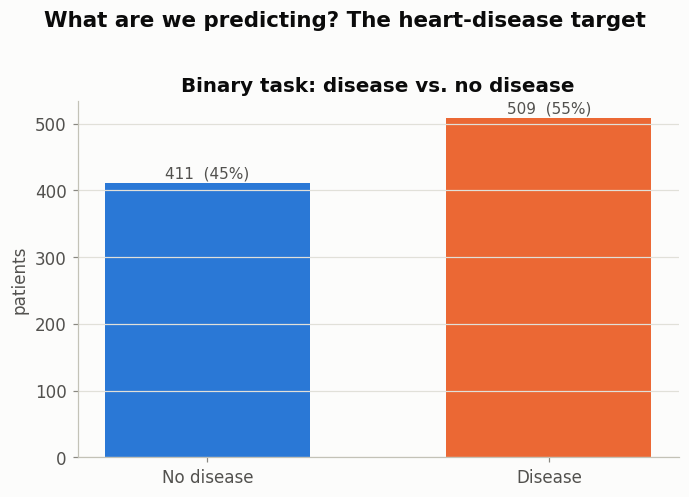

In [3]:
print('raw target values present:', sorted(df['target'].unique()))
print('binary class counts:')
print((df['target'] > 0).map({False:'No disease', True:'Disease'}).value_counts())
eda.plot_target_distribution(df);

The cohort is close to balanced (~45% no disease / ~55% disease) — but that overall balance is misleading, because it differs a lot by site:

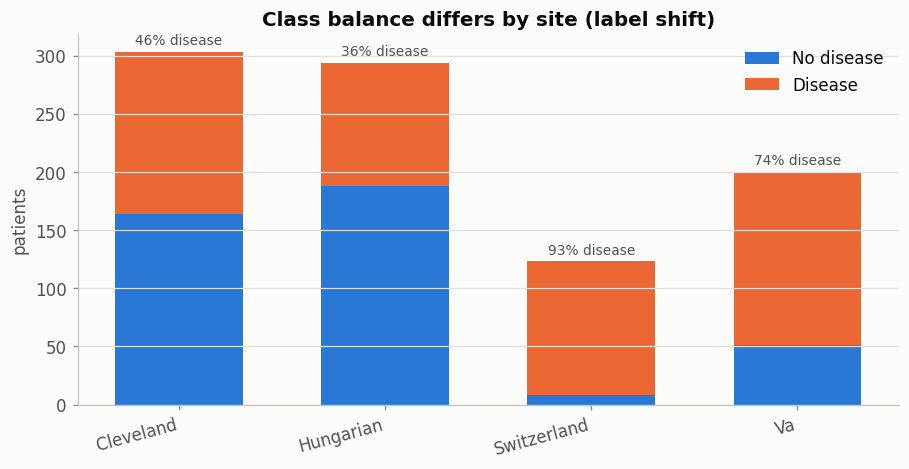

In [4]:
eda.plot_target_by_site(df);

## The 13 features
Five are **continuous** (age, resting blood pressure, cholesterol, max heart rate, ST depression) and eight are **categorical / ordinal** (sex, chest-pain type, fasting blood sugar, resting ECG, exercise angina, ST slope, #vessels, thalassemia test). The full data dictionary is in the `eda` module docstring:

In [5]:
print(eda.__doc__)


Exploratory data analysis (EDA) for the raw UCI Heart Disease inputs.

Before any modeling, attendees should *see* the inputs: what the target classes
are, which features are categorical vs. continuous, how they relate to the
outcome, and how all of this differs across the four hospital sites. These
helpers produce that first-look picture.

Feature dictionary (raw UCI coding)
-----------------------------------
age       : age in years                                     (continuous)
sex       : 1 = male, 0 = female                             (binary)
cp        : chest pain type -- 1 typical angina, 2 atypical,
            3 non-anginal, 4 asymptomatic                    (categorical)
trestbps  : resting blood pressure (mm Hg)                   (continuous)
chol      : serum cholesterol (mg/dl); 0 = unrecorded        (continuous)
fbs       : fasting blood sugar > 120 mg/dl (1 = true)       (binary)
restecg   : resting ECG -- 0 normal, 1 ST-T abnormality,
            2 left-ventricula

### Continuous features by outcome
Where the orange (disease) and blue (no-disease) curves separate, the feature is informative. Note `chol`, `trestbps`, `thalach` are shown for *measured* values only (zeros are unrecorded).

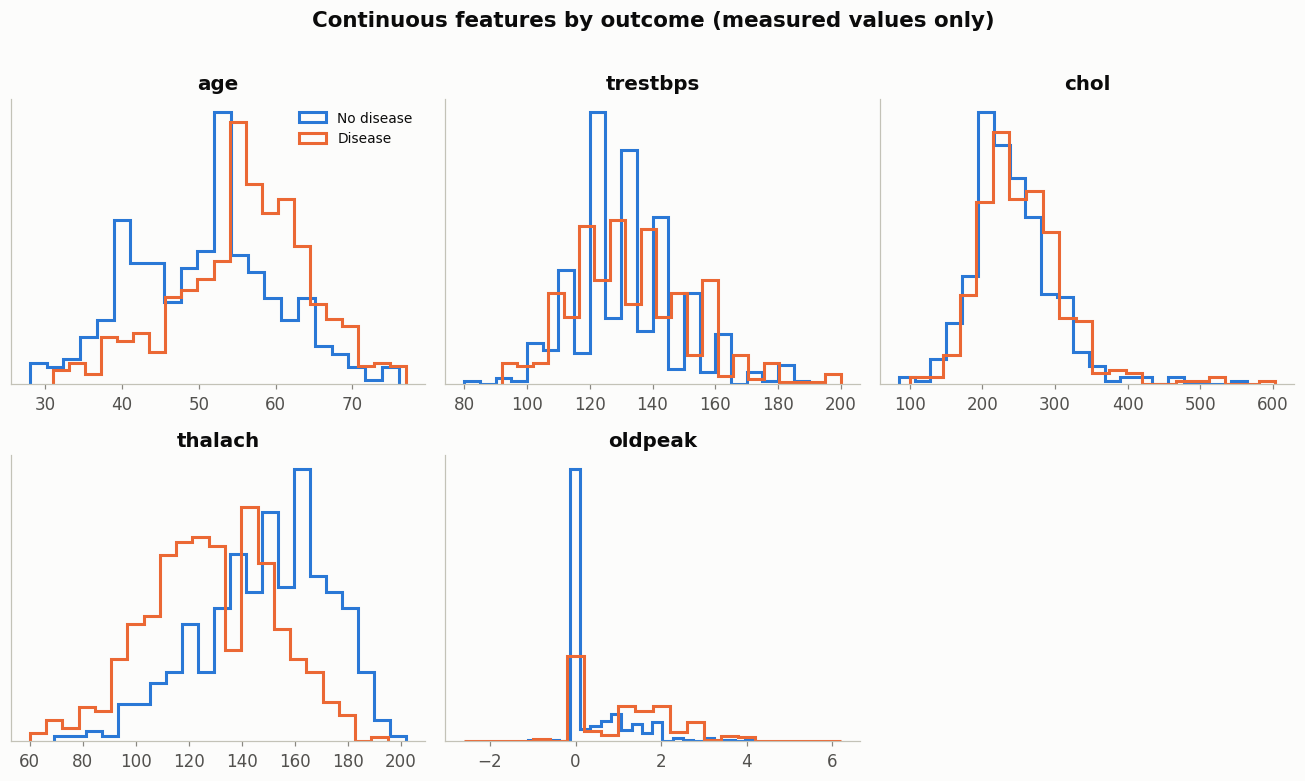

In [6]:
eda.plot_continuous_grid(df);

### Categorical features: disease rate per level
Bar height is the disease rate within each category; the dashed line is the overall rate. Asymptomatic chest pain, exercise-induced angina, a flat/down ST slope and a reversible thalassemia defect all carry sharply higher disease rates — clinically sensible.

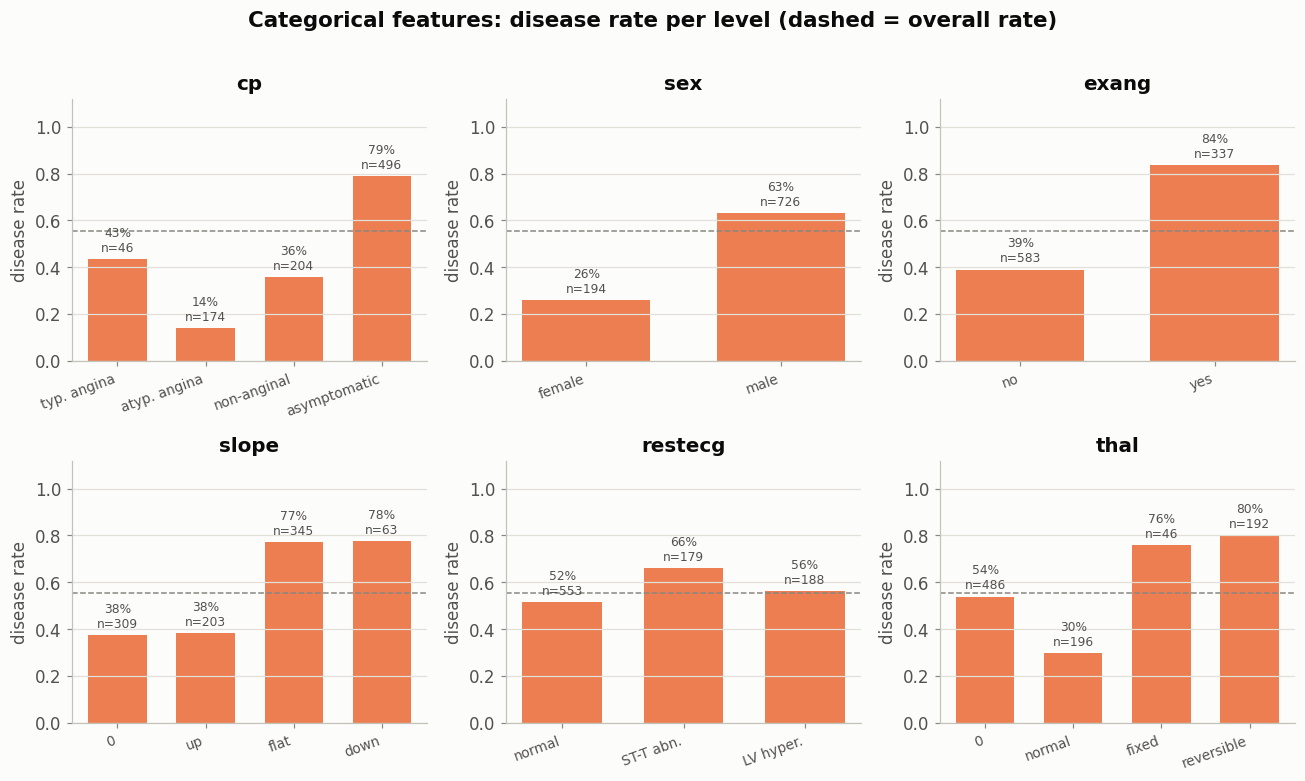

In [7]:
eda.plot_categorical_grid(df);

> **Curation note:** the `0` bars under `slope` and `thal` are *unrecorded* values coded as zero (thal is only 3/6/7 in the real coding). Spotting these is exactly the measurement-heterogeneity check the workshop is about.

### One feature across sites
Maximum heart rate achieved, by site — a quick look at how the same measurement shifts between hospitals.

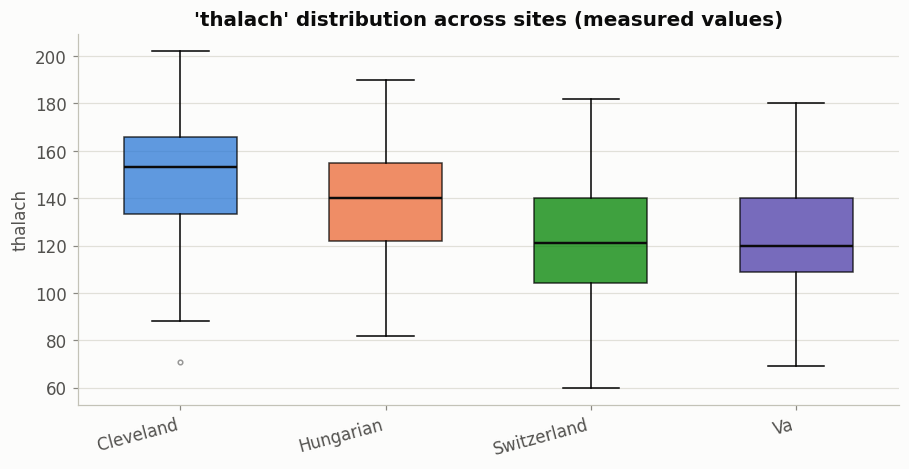

In [8]:
eda.plot_feature_boxplots_by_site(df, 'thalach');

### Correlation structure
How features move together and with the outcome. `cp`, `exang`, `oldpeak`, `thalach` and `ca` are among the strongest correlates of disease.

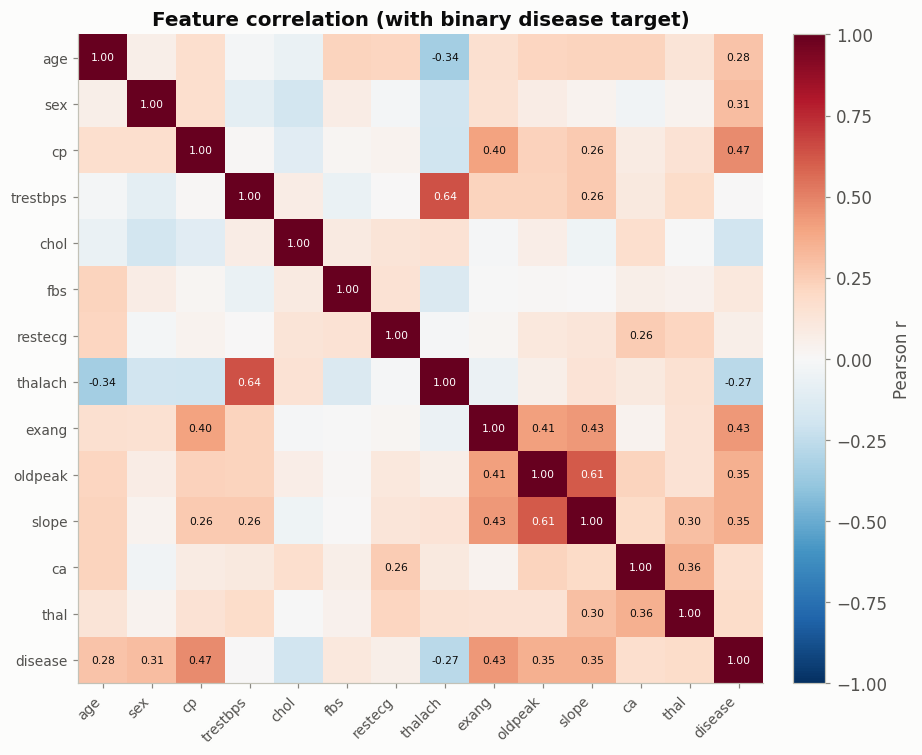

In [9]:
eda.plot_correlation_heatmap(df);

### Exercise
1. Call `eda.plot_feature_boxplots_by_site(df, 'age')` and `'trestbps'`. Which feature is most consistent across sites, and which is most shifted?
2. Using `df`, compute the disease rate for males vs females *within each site*. Does the sex effect look the same everywhere? (This previews the heterogeneity notebook.)